In [143]:
import os, sys

# Make sure we're in the project root
os.chdir("/Users/danesh/Documents/GitHub/trueQ")

# Ensure project root is on sys.path
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from config import *
from cer import *

In [144]:
strength = [1,2,3,4]
strength_scales = [0.5, 1.0, 1.5, 2]
x_rotation_strengths = [0.014236438 * scale for scale in strength_scales]

In [145]:
t_gate_rotation = 0.180213
h_gate_rotation = 0.1
cnot_gate_rotation = 0.073675

In [146]:
def zxzxz_simulators():

    zxzxz_dict = {gate: ZXZXZ_decompose(tq.Circuit([{0:gate}])) for gate in clifford_gates}

    easy_gate_circuits = [ZXZXZ_decompose(tq.Circuit([{0:easy}])) for easy in easy_gates]
    zxzxz_simulators = {}
    noisy_easy_gates = {}

    for label, x_strength in zip(strength, x_rotation_strengths):

        sim = tq.Simulator()
        
        noisy_sim = (
            sim.add_overrotation(single_sys=x_strength, match=tqs.GateMatch(tq.Gate.sx))
                .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot)
        )
        infidelity = 1 - sum([process_fidelity(circ, noisy_sim) for circ in easy_gate_circuits]) / len(easy_gate_circuits)

        zxzxz_simulators[label] = (noisy_sim, infidelity)
        noisy_easy_gates[label] = {gate: zxzxz_simulators[label][0].operator(zxzxz_dict[gate]).mat() for gate in clifford_gates}

    def gate_replace_1(gate):
        return tq.Gate(noisy_easy_gates[1][gate])

    def gate_replace_2(gate):
        return tq.Gate(noisy_easy_gates[2][gate])

    def gate_replace_3(gate):
        return tq.Gate(noisy_easy_gates[3][gate])

    def gate_replace_4(gate):
        return tq.Gate(noisy_easy_gates[4][gate])

    sim1 = tq.Simulator()
    noisy_sim_1 = (
            sim1.add_gate_replace(gate_replace_1, match=match_clifford)
                .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot)
        )

    sim2 = tq.Simulator()
    noisy_sim_2 = (
            sim2.add_gate_replace(gate_replace_2, match=match_clifford)
                .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot)
        )

    sim3 = tq.Simulator()
    noisy_sim_3 = (
            sim3.add_gate_replace(gate_replace_3, match=match_clifford)
                .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot)
        )

    sim4 = tq.Simulator()
    noisy_sim_4 = (
            sim4.add_gate_replace(gate_replace_4, match=match_clifford)
                .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot)
        )

    final_sims = {}
    zxzxz_simulators_final = {}

    final_sims[1] = noisy_sim_1
    final_sims[2] = noisy_sim_2
    final_sims[3] = noisy_sim_3
    final_sims[4] = noisy_sim_4

    for label in strength:
        zxzxz_simulators_final[label] = (final_sims[label], zxzxz_simulators[label][1])

    return zxzxz_simulators_final

sim_ZXZXZ = zxzxz_simulators()

In [147]:
noisy_sim_dep = sim_ZXZXZ[4][0]

In [148]:
def noisy_paulis(sim: tq.Simulator):
    noisy_gates = {}
    for gate in paulis:
        noisy_gates[gate] = tq.Gate(sim.operator(tq.Circuit([{0: gate}])).mat())
    return noisy_gates

def noisy_dihedral(sim: tq.Simulator):
    noisy_gates = {}
    for gate in easy_gates:
        noisy_gates[gate] = tq.Gate(sim.operator(tq.Circuit([{0: gate}])).mat())
    return noisy_gates

def noise(noisy_gates):
    noise = {}
    for gate in noisy_gates:
        noise[gate] = noisy_gates[gate]@gate.adj
    return noise

def avg_noise(noise):
    superop = {}
    for gate in noise:
        superop[gate] = tqm.Superop.from_unitary(tq.Simulator().operator(tq.Circuit([{0: noise[gate]}])).mat()).ptm
    
    return tqm.Superop.from_ptm(sum(superop.values())/len(superop))

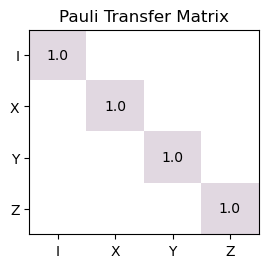

In [150]:
noise_superop = avg_noise(noise(noisy_paulis(noisy_sim_dep)))
noise_superop.plot_ptm()

In [151]:
pauli_gate_independent_noise = {pauli: (noise_superop@tqm.Superop.from_unitary(pauli.mat)) for pauli in paulis}

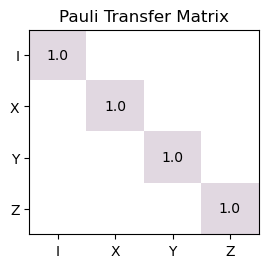

In [152]:
noise_superop.plot_ptm()

In [153]:
def gate_replace(gate):
    if gate in paulis:
        return pauli_gate_independent_noise[gate]

In [155]:
noisy_sim_gate_indep =  (tq.Simulator().add_gate_replace(gate_replace, match = tqs.GateMatch(paulis)) 
                            .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                            .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                            .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot))

In [154]:
noisy_sim_gate_error_free =  (tq.Simulator().add_overrotation(single_sys=t_gate_rotation, match=match_t)
                                       .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                                       .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot))

In [158]:
cb_circs = tq.make_cb(cycles=tq.Cycle({0:tq.Gate.h}), n_random_cycles= [2,4,6,8,12], n_circuits= 2000, n_decays=4)

         (/opt/miniconda3/envs/new_qiskit/lib/python3.12/site-packages/trueq/simulation/simulator.py:273)


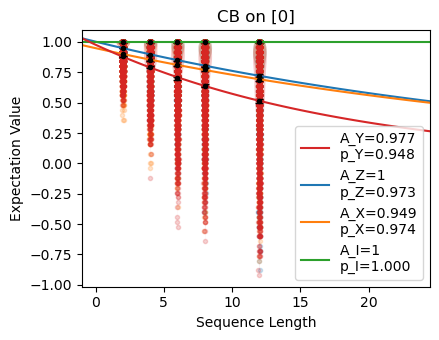

In [165]:
noisy_sim_dep.run(cb_circs)

cb_circs.plot.raw()

In [166]:
cb_circs.fit()

CB Cycle Benchmarking,"Paulis (0,) : Gate.h Key: cycles: (Cycle((0,): Gate.h),) labels: (0,) protocol: CB twirl: Paulis on [0]"
${e}_{I}$ The probability of the subscripted error acting on the specified labels.,"9.7e-01 (6.1e-04) 0.973774261042571, 0.0006096327504515134"
${e}_{F}$ The probability of an error acting on the specified labels during a dressed cycle of interest.,"2.6e-02 (6.1e-04) 0.026225738957428968, 0.0006096327504515134"
${p}_{Z}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (9.1e-04) 0.9729179603614191, 0.0009099199295288476"
${p}_{Y}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.5e-01 (1.6e-03) 0.9480681784998155, 0.0015949899502691464"
${p}_{X}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (1.0e-03) 0.9741109053090494, 0.0010430138376184511"
${p}_{I}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.3e-19) 1.0, 1.2592382200645048e-19"
${A}_{Z}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (4.4e-03) 1.002825018087278, 0.00443781389611026"
${A}_{Y}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.8e-01 (7.8e-03) 0.9774935187372641, 0.007753348106610546"
${A}_{X}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.5e-01 (5.2e-03) 0.9492458272363309, 0.005163927803311135"
${A}_{I}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.0e-18) 1.0, 1.0388715315532165e-18"


         (/opt/miniconda3/envs/new_qiskit/lib/python3.12/site-packages/trueq/simulation/simulator.py:273)


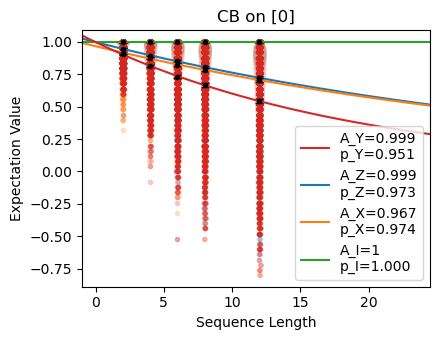

In [167]:
noisy_sim_gate_indep.run(cb_circs)

cb_circs.plot.raw()

In [168]:
cb_circs.fit()

CB Cycle Benchmarking,"Paulis (0,) : Gate.h Key: cycles: (Cycle((0,): Gate.h),) labels: (0,) protocol: CB twirl: Paulis on [0]"
${e}_{I}$ The probability of the subscripted error acting on the specified labels.,"9.7e-01 (5.6e-04) 0.9745073108522786, 0.0005551864004323647"
${e}_{F}$ The probability of an error acting on the specified labels during a dressed cycle of interest.,"2.5e-02 (5.6e-04) 0.025492689147721403, 0.0005551864004323647"
${p}_{Z}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (8.6e-04) 0.9734207564439583, 0.0008599637699427495"
${p}_{Y}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.5e-01 (1.4e-03) 0.9505288494604796, 0.001433649495541328"
${p}_{X}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (9.5e-04) 0.9740796375046763, 0.0009507337739980119"
${p}_{I}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.2e-19) 1.0, 1.2131613062083216e-19"
${A}_{Z}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (4.2e-03) 0.9992503244879237, 0.004201261426072612"
${A}_{Y}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (7.0e-03) 0.9990612964297738, 0.0070492016478908796"
${A}_{X}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (4.7e-03) 0.9674505222950384, 0.0047271563460889055"
${A}_{I}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.0e-18) 1.0, 1.0008580776218653e-18"


         (/opt/miniconda3/envs/new_qiskit/lib/python3.12/site-packages/trueq/simulation/simulator.py:273)


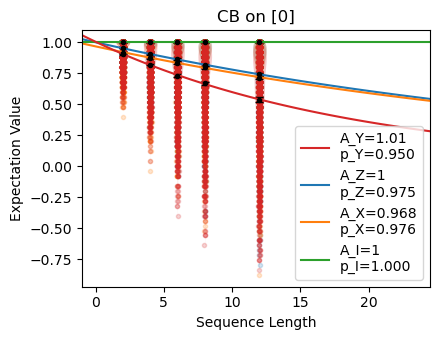

In [169]:
noisy_sim_gate_error_free.run(cb_circs)

cb_circs.plot.raw()

In [170]:
cb_circs.fit()

CB Cycle Benchmarking,"Paulis (0,) : Gate.h Key: cycles: (Cycle((0,): Gate.h),) labels: (0,) protocol: CB twirl: Paulis on [0]"
${e}_{I}$ The probability of the subscripted error acting on the specified labels.,"9.8e-01 (5.6e-04) 0.9751125134446691, 0.0005606378260607694"
${e}_{F}$ The probability of an error acting on the specified labels during a dressed cycle of interest.,"2.5e-02 (5.6e-04) 0.024887486555330907, 0.0005606378260607694"
${p}_{Z}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.8e-01 (8.5e-04) 0.9753705326401395, 0.000851576426613843"
${p}_{Y}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.5e-01 (1.5e-03) 0.9495028376971655, 0.0014571835358597378"
${p}_{X}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.8e-01 (9.6e-04) 0.9755766834413715, 0.0009608386943585577"
${p}_{I}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.2e-19) 1.0, 1.199519605920294e-19"
${A}_{Z}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (4.2e-03) 1.0017627836269296, 0.004162936947947535"
${A}_{Y}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (7.2e-03) 1.00569215805211, 0.007182029447083793"
${A}_{X}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (4.8e-03) 0.9682978657257122, 0.004764779423182121"
${A}_{I}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (9.9e-19) 1.0, 9.896036748842425e-19"


In [98]:
def random_cb_circuit_no_meas(hard_gate: tq.Gate, easy_gate_set: list, depth: int):

    if hard_gate == Gate.cx:
        lst = []
        for i in range(depth):
            t1 = random.choice(easy_gate_set)
            t2 = random.choice(easy_gate_set)
            cycle = [tq.Cycle({0:t1, 1:t2}), tq.Cycle({(0,1):hard_gate}, marker=1)]
            lst.append(cycle[0])
            lst.append(cycle[1])
        t1 = random.choice(easy_gate_set)
        t2 = random.choice(easy_gate_set)
        final_cycle = tq.Cycle({0:t1, 1:t2})
        lst.append(final_cycle)
        circ = tq.Circuit(lst)
        return circ

    else:
        lst = []
        for i in range(depth):
            t = random.choice(easy_gate_set)
            cycle = [tq.Cycle({0:t}), tq.Cycle({0:hard_gate}, marker=1)]
            lst.append(cycle[0])
            lst.append(cycle[1])
        t = random.choice(easy_gate_set)
        final_cycle = tq.Cycle({0:t})
        lst.append(final_cycle)
        circ = tq.Circuit(lst)
        return circ

In [101]:
def check_off_diagonal_terms_ptm(circuit: tq.Circuit, n_randomizations: int, simulator: tq.Simulator):
    
    rc_circs = tq.randomly_compile(circuit=circuit, n_compilations=n_randomizations)

    ptms = [(tqm.Superop.from_unitary(noise(noisy_paulis(simulator))[list(rc_circ[-1].gates.values())[0]].mat).adj).ptm@tqm.Superop.from_unitary(simulator.operator(rc_circ).mat()).ptm  for rc_circ in rc_circs]
    avg_ptm = sum(ptms) / len(ptms)

    return tqm.Superop.from_ptm(avg_ptm)

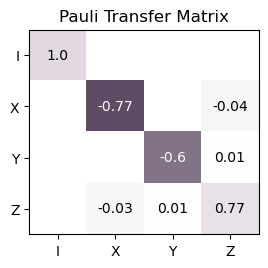

In [102]:
check_off_diagonal_terms_ptm(random_cb_circuit_no_meas(tq.Gate.h, paulis, 10), 10000, noisy_sim_dep).plot_ptm()

In [142]:
noisy_paulis(noisy_sim_gate_indep)

{Gate.x: Gate(YY, ZZ),
 Gate.y: Gate(XX, ZZ),
 Gate.z: Gate(YY, YX, ...),
 Gate.id: Gate(II)}